# Classify binary outcomes using Logistic Regression and evaluate model performance using common metrics.

#### Build a logistic regression model that predicts binary outcomes (two possible categories).
#### For this lab, use the Breast Cancer dataset available in sklearn.datasets.

### Step 1: Import Required Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

### Step 2: Load Dataset

In [32]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target") 

### Step 3: Data Preprocessing

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 4: Train Logistic Regression Model

In [35]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

### Step 5: Predictions

In [36]:
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [37]:
print("\n=== Sample Predictions on Test Data ===")
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability (Benign)": y_proba
})
print(results_df.head(10))


=== Sample Predictions on Test Data ===
   Actual  Predicted  Probability (Benign)
0       0          0          5.888242e-08
1       1          1          9.999887e-01
2       0          0          6.410825e-03
3       1          1          5.335085e-01
4       0          0          6.525001e-10
5       1          1          9.921604e-01
6       1          1          9.999828e-01
7       0          0          5.635275e-07
8       0          0          5.431637e-05
9       0          0          8.041849e-11


### Step 6: Model Evaluation
Confusion Matrix
Accuracy, Precision, Recall

In [38]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}\n")

print("=== Confusion Matrix ===")
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=data.target_names))

=== Logistic Regression Results ===
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
ROC AUC:   0.9954

=== Confusion Matrix ===
[[41  1]
 [ 1 71]]

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Step 7: ROC Curve & AUC

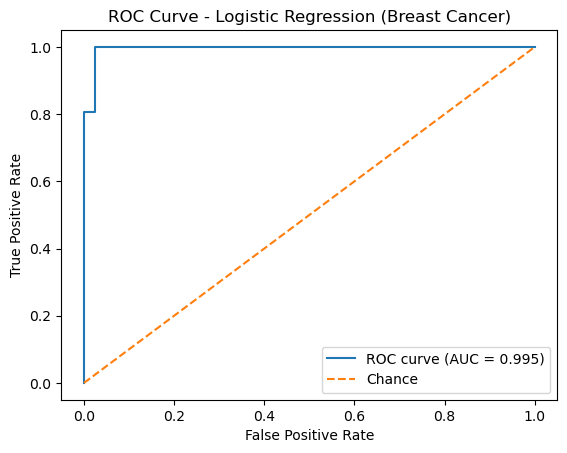

In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Breast Cancer)")
plt.legend(loc="lower right")
plt.show()